# 03 -- IC Tests
Spearman IC per factor; saves `factor_ic_results.csv`.

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')

factors = pd.read_parquet('../data/processed/factors_monthly.parquet')
art     = pd.read_parquet('../data/processed/panel_artemis_daily.parquet')

factors['date'] = pd.to_datetime(factors['date'])
art['date']     = pd.to_datetime(art['date'])
art = art.sort_values(['symbol', 'date'])

FACTOR_COLS = [
    'mom_1m', 'mom_3m', 'mom_6m', 'vol_30d',
    'fees_mc', 'rev_mc', 'fees_growth_30d', 'rev_growth_30d',
    'dau_growth_30d', 'txns_growth_30d', 'dau_zscore',
    'tvl_mc', 'tvl_growth_30d',
]

price_w = art.pivot_table(index='date', columns='symbol', values='price', aggfunc='last')
rebalance_dates = sorted(factors['date'].unique())
print(f"Factors: {factors.shape}  |  Rebalance dates: {len(rebalance_dates)}")


Factors: (2400, 15)  |  Rebalance dates: 48


In [2]:
## Compute forward returns (price at t+1 / price at t - 1)
# No lookahead: we use the rebalance date price, which is already in the past
# when the next period starts.

def last_val(wide, t, cols):
    sub = wide.reindex(columns=cols).loc[:t]
    if len(sub) == 0:
        return pd.Series(np.nan, index=cols)
    return sub.ffill().iloc[-1]

fwd_rows = []
for i, t in enumerate(rebalance_dates[:-1]):
    t_next = rebalance_dates[i + 1]
    syms = factors[factors['date'] == t]['symbol'].tolist()
    syms_in = [s for s in syms if s in price_w.columns]
    p_t  = last_val(price_w, t,      syms_in)
    p_t1 = last_val(price_w, t_next, syms_in)
    fwd  = (p_t1 / p_t.replace(0, np.nan)) - 1
    for sym, r in fwd.items():
        fwd_rows.append({'symbol': sym, 'date': t, 'fwd_ret': r})

fwd_df = pd.DataFrame(fwd_rows)
print(f"Forward returns: {fwd_df.shape}  |  NaN rate: {fwd_df['fwd_ret'].isna().mean():.2%}")
print(fwd_df['fwd_ret'].describe().round(3).to_string())


Forward returns: (2350, 3)  |  NaN rate: 0.00%
count    2350.000
mean        0.066
std         0.503
min        -1.000
25%        -0.172
50%        -0.025
75%         0.166
max         8.872


In [3]:
## Spearman IC per factor
merged = factors.merge(fwd_df, on=['symbol', 'date'], how='inner')

ic_records = []

for factor in FACTOR_COLS:
    ics = []
    for t, grp in merged.groupby('date'):
        valid = grp[[factor, 'fwd_ret']].dropna()
        if len(valid) < 5:
            continue
        ic, _ = stats.spearmanr(valid[factor], valid['fwd_ret'])
        ics.append(ic)

    ics = np.array(ics)
    n = len(ics)
    if n < 2:
        ic_records.append({'Factor': factor, 'Mean IC': np.nan, 'IC Std': np.nan,
                           't-stat': np.nan, 'Hit Rate': np.nan, 'Q5-Q1 Spread': np.nan, 'N': n})
        continue

    mean_ic  = ics.mean()
    std_ic   = ics.std(ddof=1)
    t_stat   = mean_ic / std_ic * np.sqrt(n) if std_ic > 1e-10 else 0.0
    hit_rate = (ics > 0).mean()

    spreads = []
    for t, grp in merged.groupby('date'):
        valid = grp[[factor, 'fwd_ret']].dropna()
        if len(valid) < 10:
            continue
        valid = valid.copy()
        valid['q'] = pd.qcut(valid[factor], 5, labels=False, duplicates='drop')
        q5 = valid[valid['q'] == valid['q'].max()]['fwd_ret'].mean()
        q1 = valid[valid['q'] == valid['q'].min()]['fwd_ret'].mean()
        spreads.append(q5 - q1)
    q5q1 = float(np.mean(spreads)) if spreads else np.nan

    ic_records.append({
        'Factor':       factor,
        'Mean IC':      round(mean_ic, 4),
        'IC Std':       round(std_ic,  4),
        't-stat':       round(t_stat,  2),
        'Hit Rate':     round(hit_rate, 3),
        'Q5-Q1 Spread': round(q5q1, 4) if not np.isnan(q5q1) else np.nan,
        'N':            n,
    })

ic_df = pd.DataFrame(ic_records).sort_values('t-stat', ascending=False)
print("Factor IC Summary:")
print(ic_df.to_string(index=False))
print()
sig = ic_df[ic_df['t-stat'].abs() > 1.0]['Factor'].tolist()
print(f"Factors with |t-stat| > 1.0: {sig}")


Factor IC Summary:
         Factor  Mean IC  IC Std  t-stat  Hit Rate  Q5-Q1 Spread  N
 dau_growth_30d   0.0301  0.1481    1.39     0.638        0.0427 47
         rev_mc   0.0102  0.1672    0.42     0.574       -0.0054 47
     dau_zscore   0.0058  0.1427    0.28     0.489       -0.0268 47
         mom_3m   0.0021  0.1939    0.07     0.574        0.0307 47
         mom_1m   0.0021  0.1939    0.07     0.574        0.0307 47
         mom_6m   0.0021  0.1939    0.07     0.574        0.0307 47
         tvl_mc      NaN     NaN    0.00     0.468           NaN 47
 tvl_growth_30d      NaN     NaN    0.00     0.574           NaN 47
txns_growth_30d  -0.0003  0.1579   -0.01     0.489       -0.0064 47
fees_growth_30d  -0.0014  0.1492   -0.06     0.489        0.0250 47
        fees_mc  -0.0124  0.1584   -0.53     0.447       -0.0108 47
 rev_growth_30d  -0.0153  0.1366   -0.77     0.426       -0.0022 47
        vol_30d  -0.1299  0.2726   -3.27     0.298       -0.0178 47

Factors with |t-stat| > 1.0:

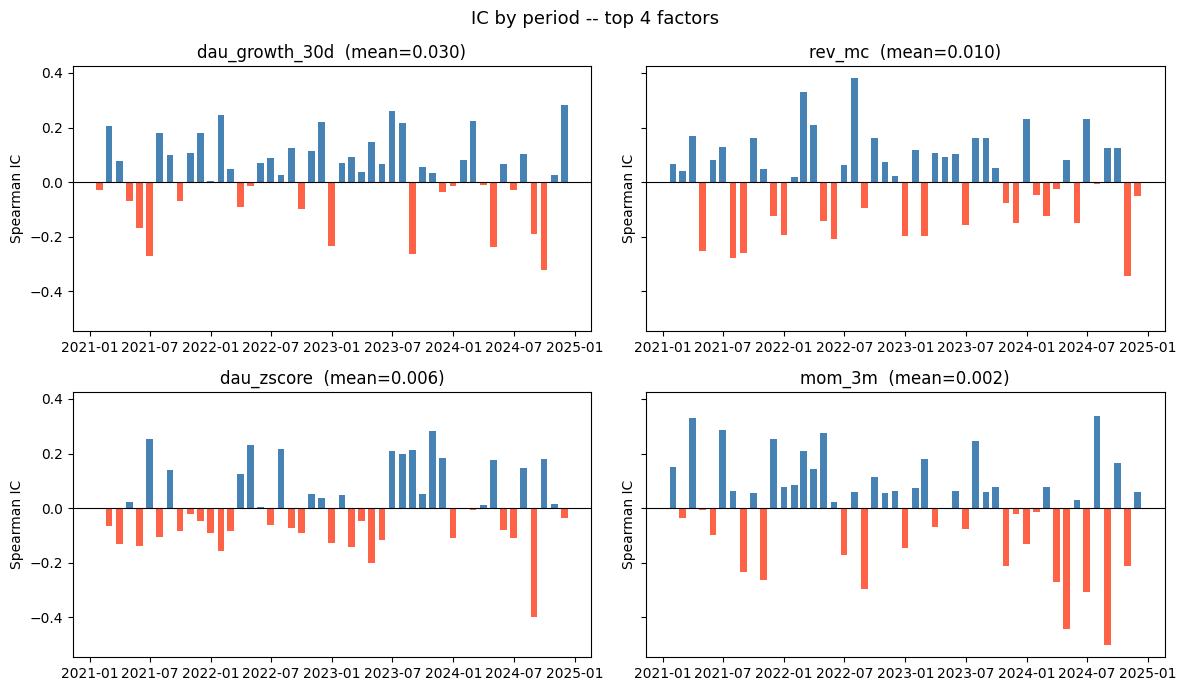

In [4]:
## IC bar chart for top 4 factors by |t-stat|
top_factors = ic_df.head(4)['Factor'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for ax, factor in zip(axes, top_factors):
    ics, dates = [], []
    for t, grp in merged.groupby('date'):
        valid = grp[[factor, 'fwd_ret']].dropna()
        if len(valid) < 5:
            continue
        ic, _ = stats.spearmanr(valid[factor], valid['fwd_ret'])
        ics.append(ic); dates.append(t)
    ax.bar(dates, ics, color=['steelblue' if ic > 0 else 'tomato' for ic in ics], width=20)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'{factor}  (mean={float(np.mean(ics)):.3f})')
    ax.set_ylabel('Spearman IC')

plt.suptitle('IC by period -- top 4 factors', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/ic_by_period.png', dpi=100, bbox_inches='tight')
plt.show()


In [5]:
out_path = '../data/processed/factor_ic_results.csv'
ic_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print("\n>> IC tests complete.")


Saved: ../data/processed/factor_ic_results.csv

>> IC tests complete.
